LOADING REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
#IMPORTING THE DATASET

df=pd.read_csv("delhivery_data.csv")

INTITAL EXPLORATION

In [3]:
df.shape

(144867, 24)

In [4]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [6]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


MISSING VALUE ANALYSIS

In [7]:
df.isnull().sum()

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [8]:
(df.isnull().sum()/len(df))*100

data                              0.000000
trip_creation_time                0.000000
route_schedule_uuid               0.000000
route_type                        0.000000
trip_uuid                         0.000000
source_center                     0.000000
source_name                       0.202254
destination_center                0.000000
destination_name                  0.180165
od_start_time                     0.000000
od_end_time                       0.000000
start_scan_to_end_scan            0.000000
is_cutoff                         0.000000
cutoff_factor                     0.000000
cutoff_timestamp                  0.000000
actual_distance_to_destination    0.000000
actual_time                       0.000000
osrm_time                         0.000000
osrm_distance                     0.000000
factor                            0.000000
segment_actual_time               0.000000
segment_osrm_time                 0.000000
segment_osrm_distance             0.000000
segment_fac

In [9]:
df.duplicated().sum()

np.int64(0)

CONVERTING DATE ENTRIES FROM OBJECT TO DATE TYPE

In [10]:
date_cols=["trip_creation_time","od_start_time","od_end_time","cutoff_timestamp"]

for col in date_cols:
    df[col]=pd.to_datetime(df[col],format='mixed')

In [11]:
df[date_cols].dtypes

trip_creation_time    datetime64[ns]
od_start_time         datetime64[ns]
od_end_time           datetime64[ns]
cutoff_timestamp      datetime64[ns]
dtype: object

AGGREGATION AT CORRIDOR LEVEL

In [12]:
corridor_df=df.groupby(['trip_uuid','source_center','destination_center']).agg(
    {
        'trip_creation_time':'first',
        'route_type':'first',
        'source_name':'first',
        'destination_name':'last',
        'actual_time':'sum',
        'osrm_time':'sum',
        'segment_actual_time':'sum',
        'segment_osrm_time':'sum',
        'osrm_distance':'sum',
        'segment_osrm_distance':'sum',
        'actual_distance_to_destination':'last',
    }
).reset_index()

In [13]:
corridor_df

,trip_uuid,source_center,destination_center,trip_creation_time,route_type,source_name,destination_name,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination
0,trip-153671041653548748,IND209304AAA,IND000000ACB,2018-09-12 00:00:16.535741,FTL,Kanpur_Central_H_6 (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),6484.0,3464.0,728.0,534.0,4540.1261,670.6205,383.759164
1,trip-153671041653548748,IND462022AAA,IND209304AAA,2018-09-12 00:00:16.535741,FTL,Bhopal_Trnsport_H (Madhya Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),9198.0,4323.0,820.0,474.0,6037.6386,649.8528,440.973689
2,trip-153671042288605164,IND561203AAB,IND562101AAA,2018-09-12 00:00:22.886430,Carting,Doddablpur_ChikaDPP_D (Karnataka),Chikblapur_ShntiSgr_D (Karnataka),96.0,55.0,46.0,26.0,60.3157,28.1995,24.644021
3,trip-153671042288605164,IND572101AAA,IND561203AAB,2018-09-12 00:00:22.886430,Carting,Tumkur_Veersagr_I (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),303.0,155.0,95.0,39.0,209.1151,55.9899,48.542890
4,trip-153671043369099517,IND000000ACB,IND160002AAC,2018-09-12 00:00:33.691250,FTL,Gurgaon_Bilaspur_HB (Haryana),Chandigarh_Mehmdpur_H (Punjab),2601.0,1427.0,608.0,231.0,1975.7409,317.7408,237.439610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26363,trip-153861115439069069,IND628204AAA,IND627657AAA,2018-10-03 23:59:14.390954,Carting,Tirchchndr_Shnmgprm_D (Tamil Nadu),Thisayanvilai_UdnkdiRD_D (Tamil Nadu),119.0,106.0,49.0,42.0,106.7084,42.1431,33.627182
26364,trip-153861115439069069,IND628613AAA,IND627005AAA,2018-10-03 23:59:14.390954,Carting,Peikulam_SriVnktpm_D (Tamil Nadu),Tirunelveli_VdkkuSrt_I (Tamil Nadu),173.0,108.0,89.0,77.0,111.8555,78.5869,33.673835
26365,trip-153861115439069069,IND628801AAA,IND628204AAA,2018-10-03 23:59:14.390954,Carting,Eral_Busstand_D (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),51.0,22.0,29.0,14.0,25.5371,16.0184,12.661945
26366,trip-153861118270144424,IND583119AAA,IND583101AAA,2018-10-03 23:59:42.701692,FTL,Sandur_WrdN1DPP_D (Karnataka),Bellary_Dc (Karnataka),278.0,59.0,233.0,42.0,76.5169,52.5303,40.546740


AGGREGATION AT TRIP LEVEL

In [14]:
trip_df = corridor_df.groupby('trip_uuid').agg({
    'trip_creation_time':'first',
    'route_type':'first',
    'source_name':'first',
    'destination_name':'last',
    'actual_time':'sum',
    'osrm_time':'sum',
    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'osrm_distance':'sum',
    'segment_osrm_distance':'sum',
    'actual_distance_to_destination':'sum'
}).reset_index()

In [15]:
trip_df

,trip_uuid,trip_creation_time,route_type,source_name,destination_name,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination
0,trip-153671041653548748,2018-09-12 00:00:16.535741,FTL,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),15682.0,7787.0,1548.0,1008.0,10577.7647,1320.4733,824.732854
1,trip-153671042288605164,2018-09-12 00:00:22.886430,Carting,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),399.0,210.0,141.0,65.0,269.4308,84.1894,73.186911
2,trip-153671043369099517,2018-09-12 00:00:33.691250,FTL,Gurgaon_Bilaspur_HB (Haryana),Gurgaon_Bilaspur_HB (Haryana),112225.0,65768.0,3308.0,1941.0,89447.2488,2545.2678,1927.404273
3,trip-153671046011330457,2018-09-12 00:01:00.113710,Carting,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),82.0,24.0,59.0,16.0,31.6475,19.8766,17.175274
4,trip-153671052974046625,2018-09-12 00:02:09.740725,FTL,Bellary_Dc (Karnataka),Sandur_WrdN1DPP_D (Karnataka),556.0,207.0,340.0,115.0,266.2914,146.7919,127.448500
...,...,...,...,...,...,...,...,...,...,...,...,...
14812,trip-153861095625827784,2018-10-03 23:55:56.258533,Carting,Chandigarh_Mehmdpur_H (Punjab),Chandigarh_Mehmdpur_H (Punjab),186.0,148.0,82.0,62.0,162.9473,64.8551,57.762332
14813,trip-153861104386292051,2018-10-03 23:57:23.863155,Carting,FBD_Balabhgarh_DPC (Haryana),Faridabad_Blbgarh_DC (Haryana),33.0,19.0,21.0,11.0,26.5333,16.0883,15.513784
14814,trip-153861106442901555,2018-10-03 23:57:44.429324,Carting,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),549.0,134.0,281.0,88.0,162.8499,104.8866,38.684839
14815,trip-153861115439069069,2018-10-03 23:59:14.390954,Carting,Tirunelveli_VdkkuSrt_I (Tamil Nadu),Tirchchndr_Shnmgprm_D (Tamil Nadu),600.0,446.0,258.0,221.0,449.5383,223.5324,134.723836


CREATING FEATURES FOR ANALYSIS

In [16]:
trip_df['month'] = trip_df['trip_creation_time'].dt.month
trip_df['year'] = trip_df['trip_creation_time'].dt.year
trip_df['day'] = trip_df['trip_creation_time'].dt.day
trip_df['weekday'] = trip_df['trip_creation_time'].dt.day_name()

EXTRACTING SOURCE AND DESTINATION STATE

In [17]:
trip_df['source_state']=trip_df['source_name'].str.extract(r'\((.*?)\)')
trip_df['destination_state']=trip_df['destination_name'].str.extract(r'\((.*?)\)')

In [18]:
trip_df['source_state']

0        Uttar Pradesh
1            Karnataka
2              Haryana
3          Maharashtra
4            Karnataka
             ...      
14812           Punjab
14813          Haryana
14814    Uttar Pradesh
14815       Tamil Nadu
14816        Karnataka
Name: source_state, Length: 14817, dtype: object

CHECKING FOR MISSING VALUES IN THE NEWLY CREATED TABLE

In [19]:
trip_df['source_state'].isna().sum()

np.int64(10)

In [20]:
trip_df.loc[trip_df['source_state'].isna(),['source_name']]

,source_name
8762,None
9835,None
10562,None
11468,None
12097,None
13104,None
13168,None
13644,None
13793,None
14199,None


DROPPING THESE ROWS - 10 MISSING SOURCE NAMES OUT OF 144,867 ~ 0.0069%

In [21]:
trip_df = trip_df.dropna(subset=['source_name'])

CALCULATING TRIP TIME / OD TIME

In [22]:
df['od_duration']=(df['od_end_time'] - df['od_start_time']).dt.total_seconds()/60

COMPARING OD DURATION AND START SCAN TIME

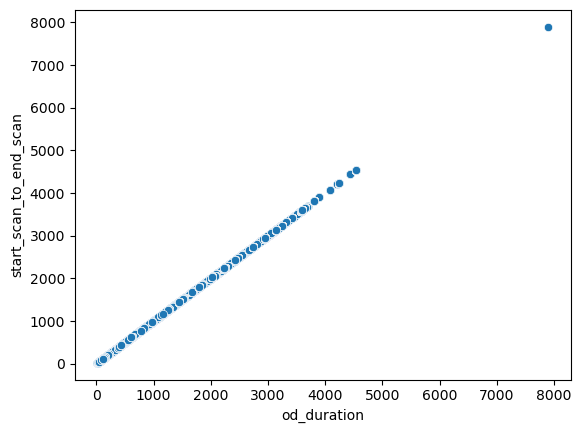

In [23]:
sns.scatterplot(x=df['od_duration'],y=df['start_scan_to_end_scan'])

plt.show()

In [24]:
df[['od_duration','start_scan_to_end_scan']].corr()

,od_duration,start_scan_to_end_scan
od_duration,1.0,1.0
start_scan_to_end_scan,1.0,1.0


HYPOTHESIS TESTING

In [25]:
#COMAPRISON I (ACTUAL TIME VS OSRM TIME)

from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(trip_df['actual_time'],trip_df['osrm_time'])
p_value,t_stat

(np.float64(1.955236157969422e-223), np.float64(32.46688399719858))

<Axes: >

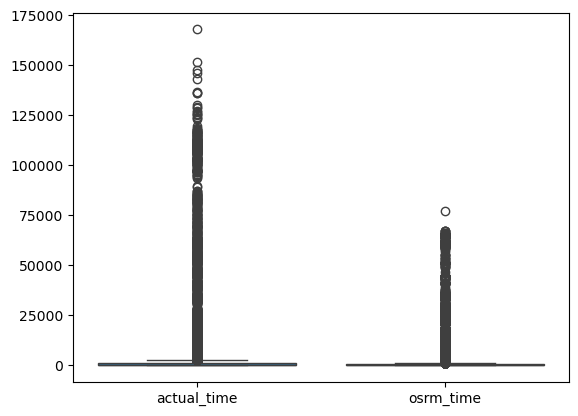

In [26]:
#VISUAL ANALYSIS OF THE ABOVE

sns.boxplot(data=trip_df[['actual_time','osrm_time']])

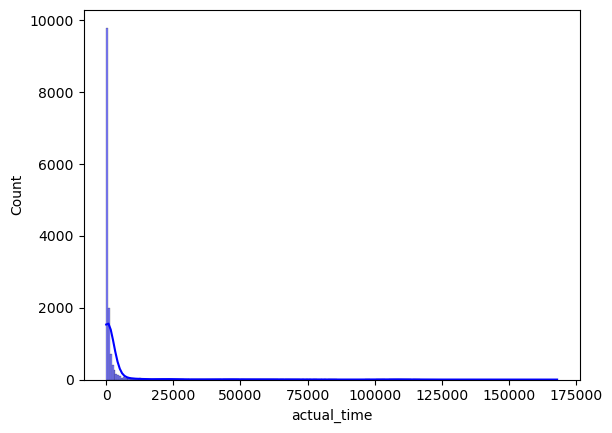

In [27]:
sns.histplot(trip_df['actual_time'],kde=True,color='blue',label='Actual')

plt.show()

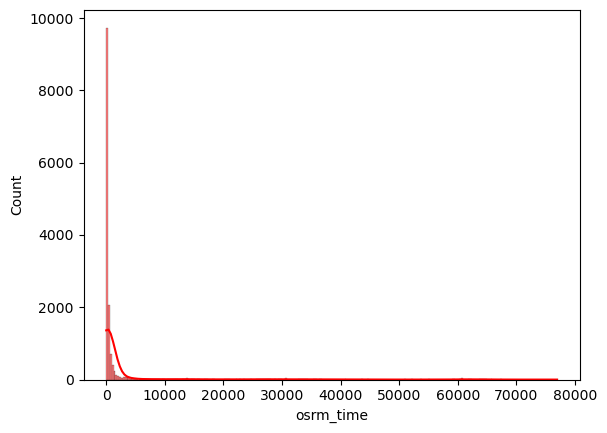

In [28]:
sns.histplot(trip_df['osrm_time'],kde=True,color='red')

plt.show()

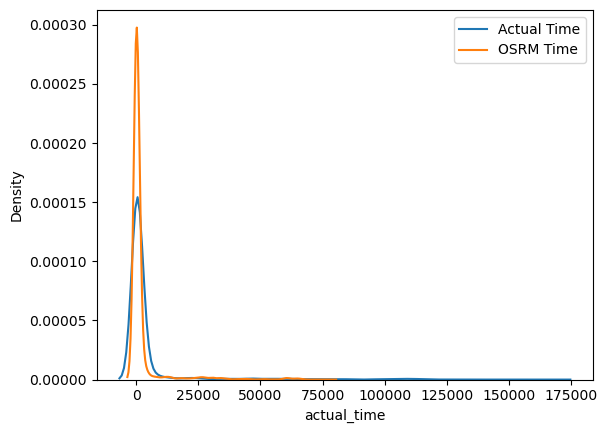

In [29]:
sns.kdeplot(trip_df['actual_time'],label='Actual Time')
sns.kdeplot(trip_df['osrm_time'],label='OSRM Time')

plt.legend()
plt.show()

In [30]:
trip_df['actual_time'].describe()

count     14807.000000
mean       4078.797596
std       15221.711050
min           9.000000
25%         142.000000
50%         348.000000
75%        1064.000000
max      167920.000000
Name: actual_time, dtype: float64

In [31]:
trip_df[['actual_time','osrm_time']].describe()

,actual_time,osrm_time
count,14807.000000,14807.000000
mean,4078.797596,2092.244006
std,15221.711050,7959.425517
min,9.000000,6.000000
25%,142.000000,62.000000
50%,348.000000,167.000000
75%,1064.000000,516.000000
max,167920.000000,76953.000000


In [32]:
trip_df[['actual_time','osrm_time']].skew()

actual_time    5.477139
osrm_time      5.574263
dtype: float64

<Axes: >

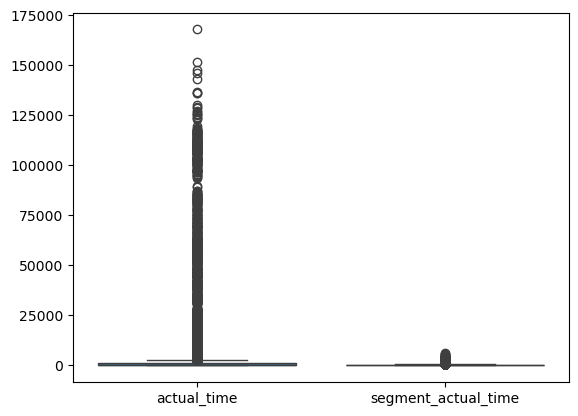

In [33]:
#COMPARISON II (ACTUAL TIME AND SEGMENT ACTUAL TIME)

sns.boxplot(data=trip_df[['actual_time','segment_actual_time']])

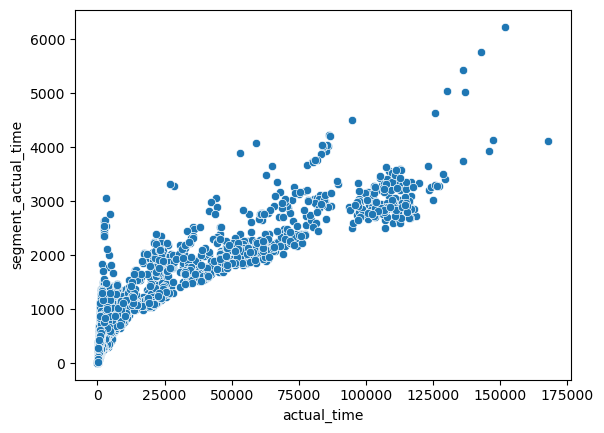

In [34]:
sns.scatterplot(x=trip_df['actual_time'],y=trip_df['segment_actual_time'])

plt.show()

In [35]:
trip_df[['actual_time','segment_actual_time']].corr()

,actual_time,segment_actual_time
actual_time,1.000000,0.874685
segment_actual_time,0.874685,1.000000


In [36]:
ttest_rel(trip_df['actual_time'],trip_df['segment_actual_time'])

TtestResult(statistic=np.float64(30.754508844560945), pvalue=np.float64(2.1583615394356942e-201), df=np.int64(14806))

In [37]:
trip_df[['actual_time','segment_actual_time']].describe()

,actual_time,segment_actual_time
count,14807.000000,14807.000000
mean,4078.797596,354.031539
std,15221.711050,556.407579
min,9.000000,9.000000
25%,142.000000,66.000000
50%,348.000000,147.000000
75%,1064.000000,367.000000
max,167920.000000,6230.000000


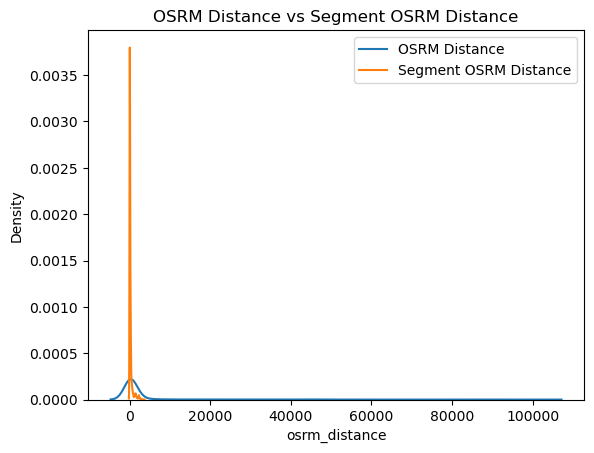

In [38]:
#COMPARISON III - (OSRM DISTANCE VS SEGMENT OSRM DISTANCE)

sns.kdeplot(trip_df['osrm_distance'],label='OSRM Distance')
sns.kdeplot(trip_df['segment_osrm_distance'], label='Segment OSRM Distance')

plt.legend()
plt.title("OSRM Distance vs Segment OSRM Distance")

plt.show()

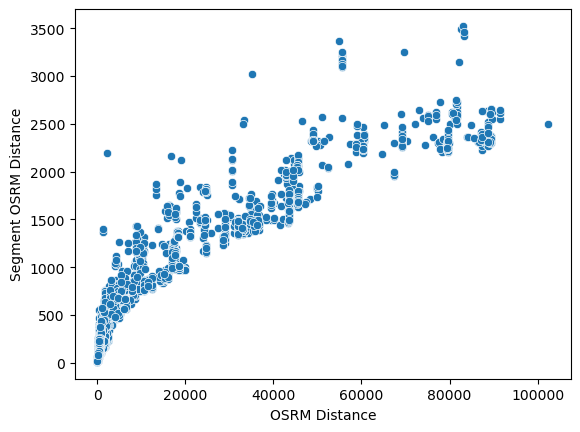

In [39]:
sns.scatterplot(x=trip_df['osrm_distance'], y=trip_df['segment_osrm_distance'])

plt.xlabel("OSRM Distance")
plt.ylabel("Segment OSRM Distance")

plt.show()

In [40]:
trip_df[['osrm_distance','segment_osrm_distance']].corr()

,osrm_distance,segment_osrm_distance
osrm_distance,1.000000,0.911177
segment_osrm_distance,0.911177,1.000000


In [41]:
ttest_rel(trip_df['osrm_distance'],trip_df['segment_osrm_distance'])

TtestResult(statistic=np.float64(30.029329602535004), pvalue=np.float64(2.256299014924368e-192), df=np.int64(14806))

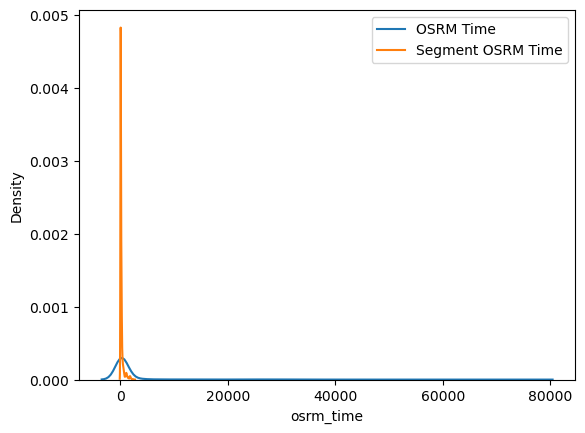

In [42]:
#COMPARISON IV (OSRM TIME VS SEGMENT OSRM TIME)

sns.kdeplot(trip_df['osrm_time'],label='OSRM Time')
sns.kdeplot(trip_df['segment_osrm_time'],label='Segment OSRM Time')

plt.legend()
plt.show()

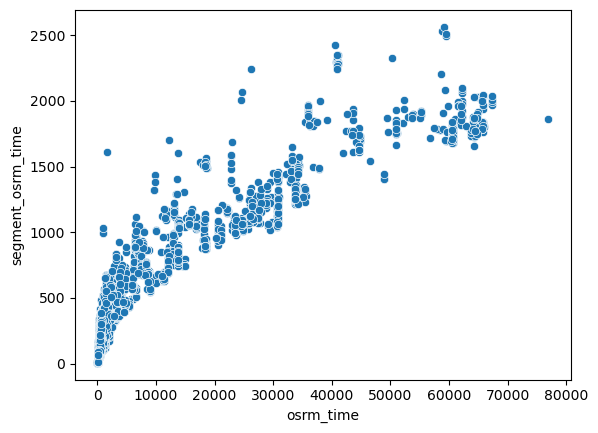

In [43]:
sns.scatterplot(x=trip_df['osrm_time'],y=trip_df['segment_osrm_time'])

plt.show()

In [44]:
trip_df[['osrm_time','segment_osrm_time']].corr()

,osrm_time,segment_osrm_time
osrm_time,1.000000,0.903184
segment_osrm_time,0.903184,1.000000


In [45]:
ttest_rel(trip_df['osrm_time'],trip_df['segment_osrm_time'])

TtestResult(statistic=np.float64(30.296253859676927), pvalue=np.float64(1.136640199143338e-195), df=np.int64(14806))

DETECTING OUTLIERS AND DEALING WITH THEM ACCORDINGLY

In [46]:
#IDENTIFYING NUMERICAL COLUMNS AND SEPARATING THEM FOR ANALYSIS

num_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'segment_osrm_time',
    'segment_osrm_distance',
    'actual_distance_to_destination']

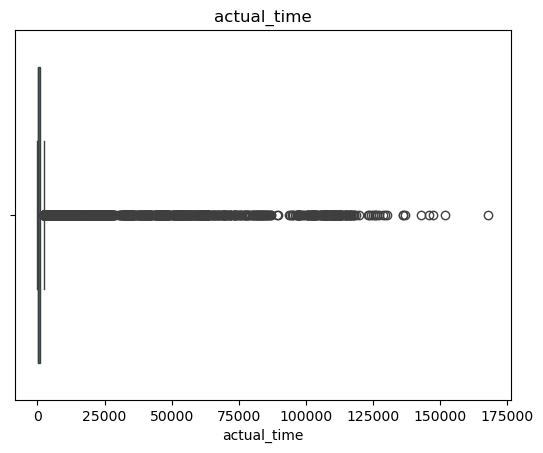

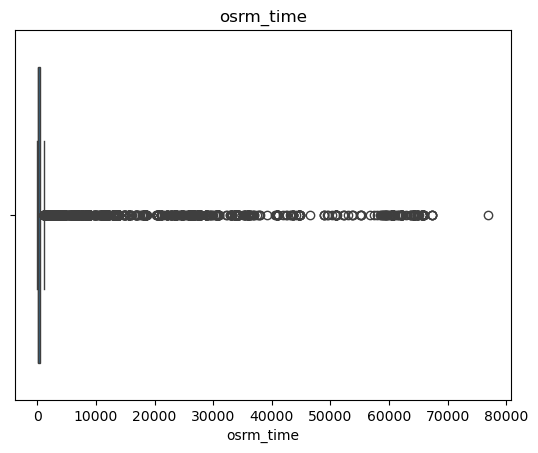

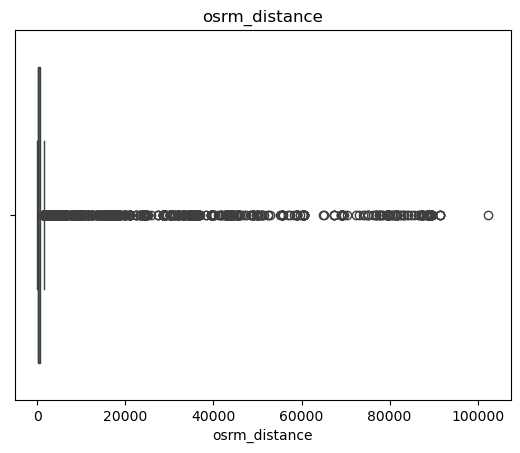

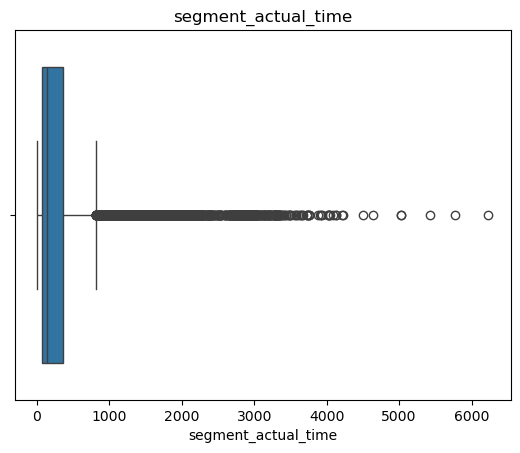

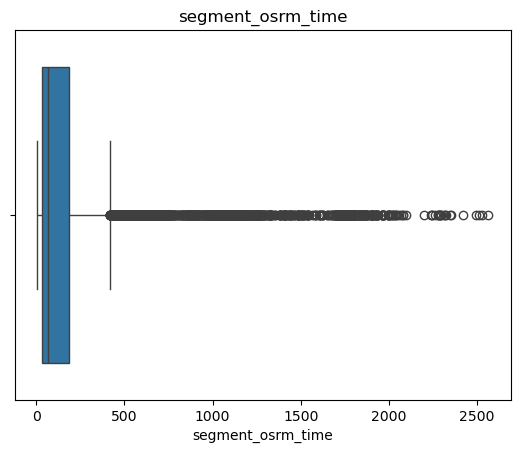

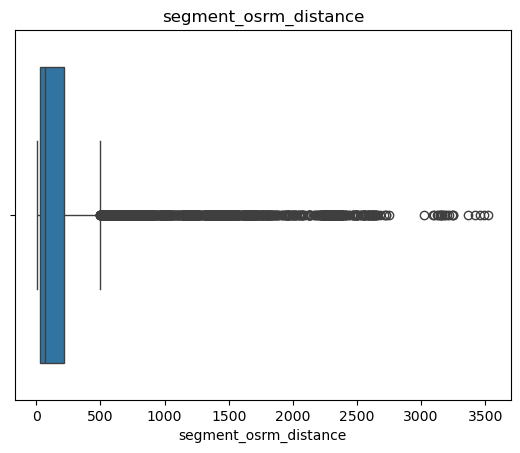

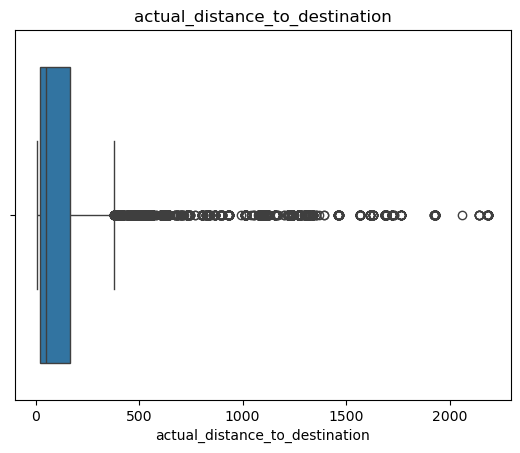

In [47]:
#VISULAIZING THEM FOR OBSERVATION

for col in num_cols:
    sns.boxplot(x=trip_df[col])
    plt.title(col)
    plt.show()

DEALING WITH OUTLIERS USING IQR METHOD

In [48]:
#FIRSTLY COUNTING THE OUTLIERS

def count_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[(df[col] < lower) |(df[col] > upper)].shape[0]


for col in num_cols:
    print(col,count_outliers(trip_df, col))

actual_time 2069
osrm_time 1948
osrm_distance 2069
segment_actual_time 1643
segment_osrm_time 1492
segment_osrm_distance 1547
actual_distance_to_destination 1449


In [49]:
#NOW REMOVING THE OUTLIERS USING IQR METHOD

def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return df[(df[col] >= lower) &(df[col] <= upper)]

In [50]:
#CALLING THE FUNCTION TO REMOVE OUTLIERS

trip_df_clean = trip_df.copy()

for col in num_cols:
    trip_df_clean = remove_outliers(trip_df_clean,col)

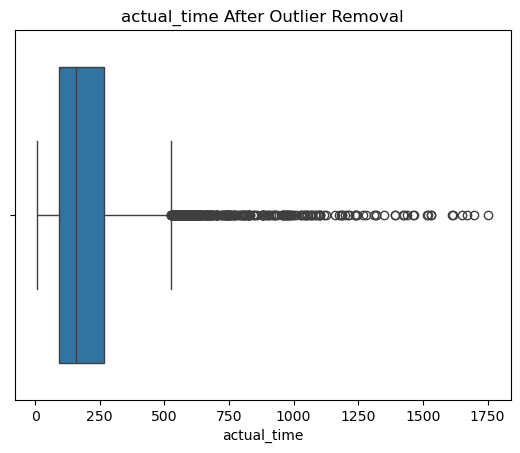

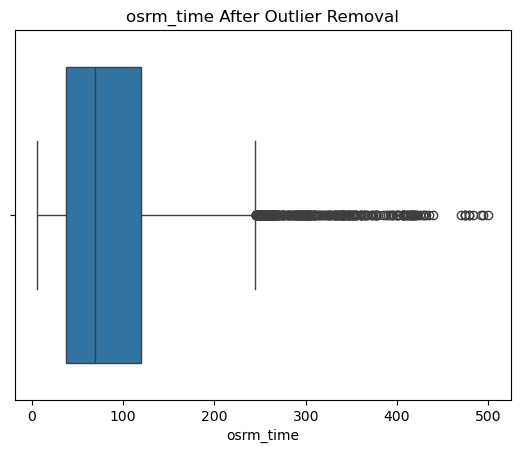

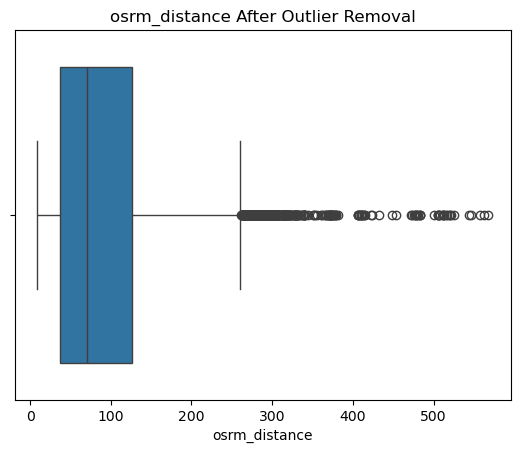

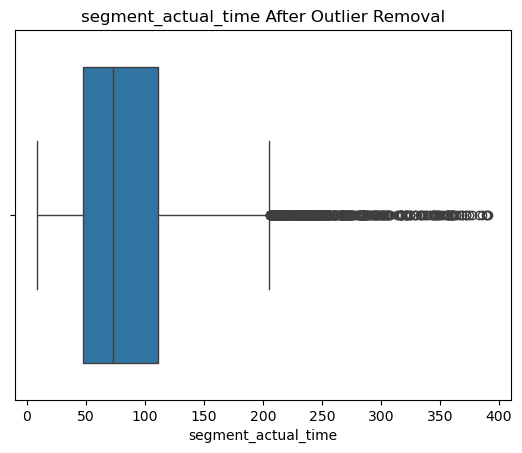

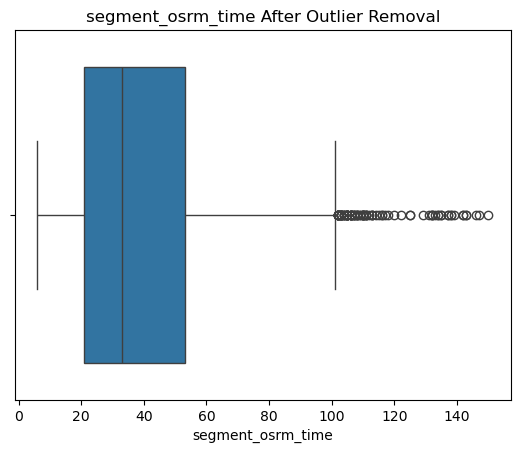

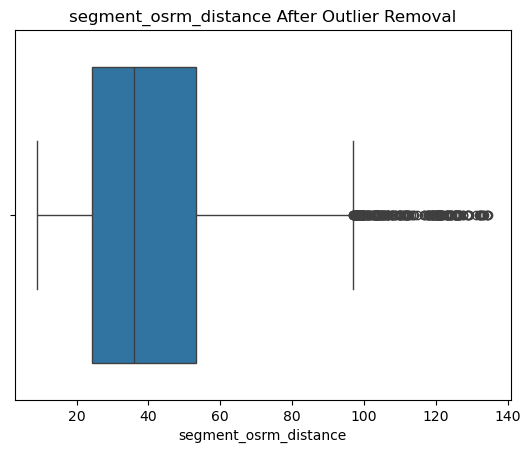

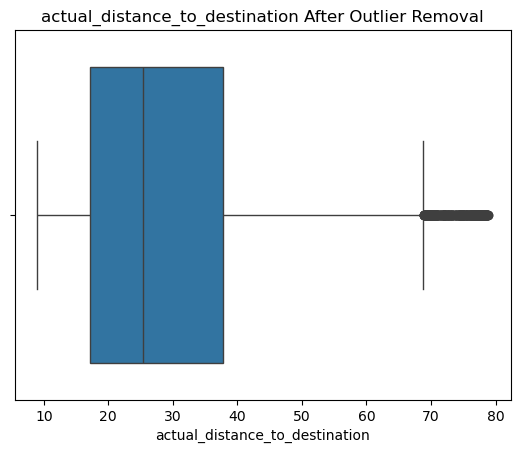

In [51]:
#VISUALLY VALIDATING ALL THE NUMERICAL COLUMNS AFTER REMOVAL OF OUTLIERS

for col in num_cols:
        sns.boxplot(
        x=trip_df_clean[col])
        plt.title(f"{col} After Outlier Removal")
        plt.show()

HANDLING CATEGORICAL VAIRABLES (ONE HOT ENCODING)

In [52]:
#IDENTIFYING CATEGORICAL VAIRABLES

trip_df_clean.select_dtypes(include=['object','category']).columns

Index(['trip_uuid', 'route_type', 'source_name', 'destination_name', 'weekday',
       'source_state', 'destination_state'],
      dtype='object')

In [53]:
#ENCODING route_type COLUMN

trip_df_clean['route_type'].value_counts()    #checking no.of categories

route_type
Carting    7615
FTL         744
Name: count, dtype: int64

In [54]:
trip_df_encoded=pd.get_dummies(trip_df_clean,columns=['route_type'],drop_first=True)

In [55]:
trip_df_encoded.head()

,trip_uuid,trip_creation_time,source_name,destination_name,actual_time,osrm_time,segment_actual_time,segment_osrm_time,osrm_distance,segment_osrm_distance,actual_distance_to_destination,month,year,day,weekday,source_state,destination_state,route_type_FTL
1,trip-153671042288605164,2018-09-12 00:00:22.886430,Doddablpur_ChikaDPP_D (Karnataka),Doddablpur_ChikaDPP_D (Karnataka),399.0,210.0,141.0,65.0,269.4308,84.1894,73.186911,9,2018,12,Wednesday,Karnataka,Karnataka,False
3,trip-153671046011330457,2018-09-12 00:01:00.113710,Mumbai Hub (Maharashtra),Mumbai_MiraRd_IP (Maharashtra),82.0,24.0,59.0,16.0,31.6475,19.8766,17.175274,9,2018,12,Wednesday,Maharashtra,Maharashtra,False
5,trip-153671055416136166,2018-09-12 00:02:34.161600,Chennai_Poonamallee (Tamil Nadu),Chennai_Poonamallee (Tamil Nadu),92.0,30.0,60.0,23.0,38.1953,28.0647,24.597048,9,2018,12,Wednesday,Tamil Nadu,Tamil Nadu,False
6,trip-153671066201138152,2018-09-12 00:04:22.011653,Chennai_Chrompet_DPC (Tamil Nadu),Chennai_Vandalur_Dc (Tamil Nadu),24.0,13.0,24.0,13.0,12.0184,12.0184,9.100510,9,2018,12,Wednesday,Tamil Nadu,Tamil Nadu,False
7,trip-153671066826362165,2018-09-12 00:04:28.263977,HBR Layout PC (Karnataka),HBR Layout PC (Karnataka),122.0,65.0,64.0,34.0,54.2978,28.9203,22.424210,9,2018,12,Wednesday,Karnataka,Karnataka,False


STANDARDIZATION / NORMALIZATION

In [56]:
#USING STANDARD SCALER TO SCALE THE NUMERICAL FEATURES

num_cols

['actual_time',
 'osrm_time',
 'osrm_distance',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'actual_distance_to_destination']

In [57]:
scaler=StandardScaler()
trip_df_encoded[num_cols]=scaler.fit_transform(trip_df_encoded[num_cols])

In [58]:
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
trip_df_encoded[num_cols].describe()

,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,actual_distance_to_destination
count,8359.000000,8359.000000,8359.000000,8359.000000,8359.000000,8359.000000,8359.000000
mean,0.000000,0.000000,-0.000000,-0.000000,0.000000,-0.000000,0.000000
std,1.000060,1.000060,1.000060,1.000060,1.000060,1.000060,1.000060
min,-1.143993,-1.184850,-1.154788,-1.354568,-1.495213,-1.387034,-1.280431
25%,-0.657145,-0.758014,-0.789824,-0.691012,-0.808908,-0.732768,-0.773434
50%,-0.270013,-0.317408,-0.347189,-0.265656,-0.259864,-0.227067,-0.248826
75%,0.357610,0.384807,0.374559,0.380886,0.655210,0.518679,0.526606
max,9.085679,5.616995,6.115474,5.144877,5.093316,4.020291,3.107617


DOING A BIT MORE ANALYSIS

In [59]:
#TOP 10 STATES WITH HIGHEST SHIPMENT GENERATION

source_state_orders = (trip_df.groupby('source_state').size().sort_values(ascending=False))

source_state_orders.head(10)

source_state
Maharashtra      2714
Karnataka        2143
Haryana          1838
Tamil Nadu       1039
Telangana         785
Uttar Pradesh     762
Gujarat           750
Delhi             728
West Bengal       665
Punjab            536
dtype: int64

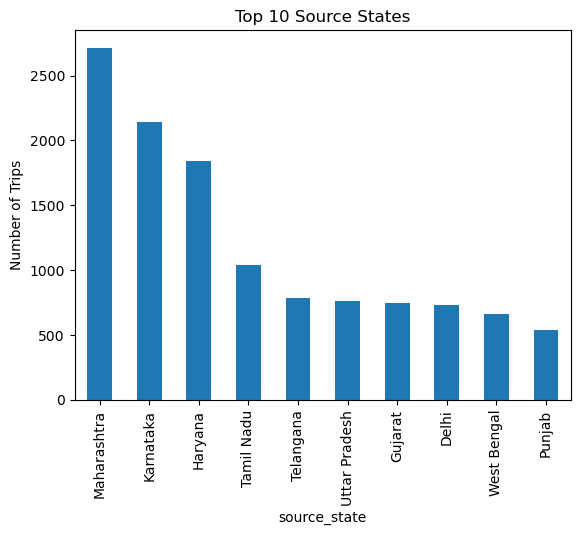

In [60]:
#VISUALIZING THE ABOVE

source_state_orders.head(10).plot(kind='bar')
plt.title("Top 10 Source States")
plt.ylabel("Number of Trips")
plt.show()

In [61]:
#TOP 10 STATES WHICH RECEIVE THE MOST NUMBER OD SHIPMENTS

destination_state_orders=(trip_df.groupby('destination_state').size().sort_values(ascending=False))

destination_state_orders.head(10)

destination_state
Maharashtra      2561
Karnataka        2294
Haryana          1643
Tamil Nadu       1084
Uttar Pradesh     811
Telangana         784
Gujarat           734
West Bengal       697
Delhi             653
Punjab            617
dtype: int64

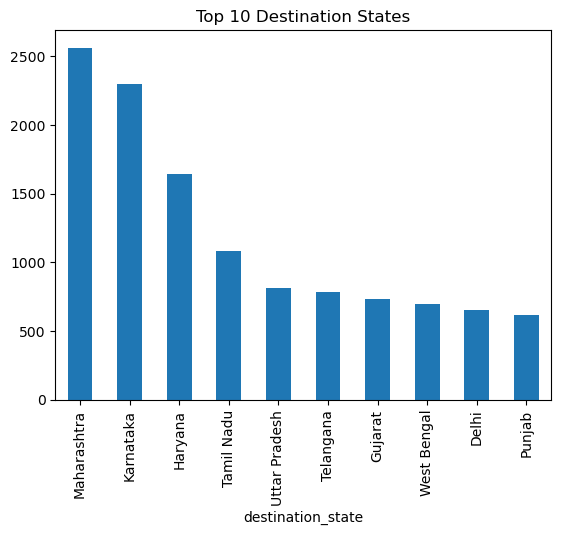

In [62]:
#VISUALIZING THE ABOVE

destination_state_orders.head(10).plot(kind='bar')
plt.title("Top 10 Destination States")
plt.show()

In [65]:
#CHEKING FOR BUSIEST CORRIDORS

trip_df=trip_df.copy()
trip_df['corridor'] = (trip_df['source_state']+" → "+trip_df['destination_state'])   #creating a new corridor feature

In [66]:
corridor_counts = (trip_df.groupby('corridor').size().sort_values(ascending=False))

corridor_counts.head(10)

corridor
Maharashtra → Maharashtra          2453
Karnataka → Karnataka              2057
Tamil Nadu → Tamil Nadu            1021
Haryana → Haryana                   949
Telangana → Telangana               689
Gujarat → Gujarat                   629
West Bengal → West Bengal           615
Uttar Pradesh → Uttar Pradesh       597
Rajasthan → Rajasthan               453
Andhra Pradesh → Andhra Pradesh     414
dtype: int64

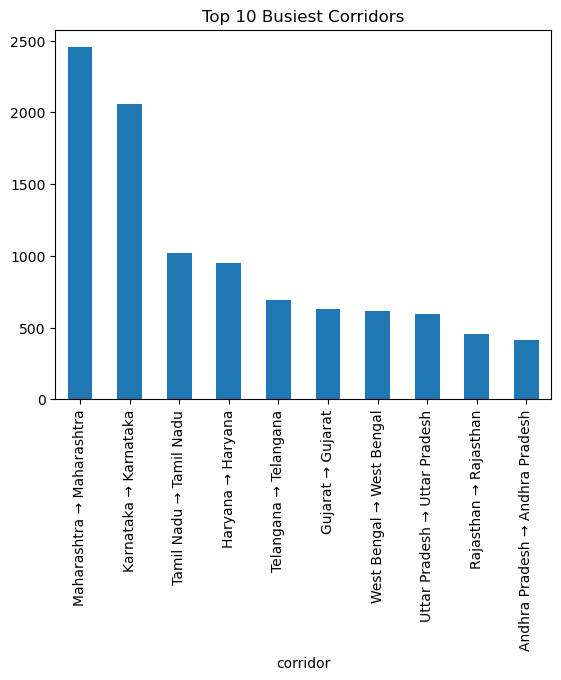

In [67]:
#VISUALIZING THE ABOVE

corridor_counts.head(10).plot(kind='bar')
plt.title("Top 10 Busiest Corridors")
plt.show()

In [70]:
#HIGHEST AVERAGE DELIVERY TIME WITHIN CORRIDORS (TOP 10)

corridor_time = (trip_df.groupby('corridor')['actual_time'].mean().sort_values(ascending=False))

corridor_time.head(10)

corridor
Punjab → Karnataka          136301.000000
Maharashtra → Assam         130199.000000
Delhi → Assam               126607.000000
Karnataka → Haryana         113721.285714
Assam → Delhi               111136.117647
Maharashtra → West Bengal   109489.333333
Haryana → Karnataka         105879.234043
Haryana → Tamil Nadu        105641.214286
Punjab → Maharashtra         82687.000000
Maharashtra → Jharkhand      82384.666667
Name: actual_time, dtype: float64

In [71]:
#PERFORMANCE BASED ON THE ROUTE TYPE

trip_df.groupby('route_type')['actual_time'].mean()

route_type
Carting    358.484621
FTL       9696.791829
Name: actual_time, dtype: float64